## 0. Library imports
These are from the FPP3 book

In [1]:
!.\venv\Scripts\python.exe -m pip install statsforecast

The system cannot find the path specified.


In [1]:
import sys
print(sys.executable)

c:\Users\tanwa\miniconda3\envs\python_development\python.exe


In [2]:
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import AutoETS
import statsmodels.api as sm
# From FPP3 book (The Pythonic Way)
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*FigureCanvasAgg is non-interactive.*"
)
import os
os.environ["NIXTLA_ID_AS_COL"] = "true"
import numpy as np
np.set_printoptions(suppress=True)
np.random.seed(1)
import random
random.seed(1)
import pandas as pd
pd.set_option("max_colwidth", 100)
pd.set_option("display.precision", 3)
from utilsforecast.plotting import plot_series as plot_series_utils
import seaborn as sns
sns.set_style("whitegrid")
import matplotlib.pyplot as plt
plt.style.use("ggplot")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 100,
    "savefig.dpi": 300,
    "figure.constrained_layout.use": True,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.title_fontsize": 10,
    "grid.alpha": 1.0,
})
import matplotlib as mpl
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler(color=["#000000", "#000000"])
from fpppy.utils import plot_series

mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#2f2fff"], name="black_and_blue"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55E00"], name="black_and_orange"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#000000"], name="black"),
    force=True,
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#569CC6", "#D55F03"],
        name='black_and_2color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076"],
        name='black_and_3color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#000000", "#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='black_and_4color',
    ),
    force=True
)
mpl.colormaps.register(
    mpl.colors.ListedColormap(
        ["#D55F03", "#569CC6", "#13A076", "#CC79A7"],
        name='r_colors',
    ),
    force=True
)

In [3]:
from functools import partial, reduce

import statsmodels.api as sm
from matplotlib.ticker import MaxNLocator
from prophet import Prophet
from statsforecast import StatsForecast
from statsforecast.adapters.prophet import AutoARIMAProphet
from statsforecast.models import MSTL, AutoETS, AutoARIMA, ARIMA
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.api import VAR
from utilsforecast.evaluation import evaluate
from utilsforecast.feature_engineering import trend, fourier, pipeline
from utilsforecast.losses import rmse, mae, mape, mase
from utilsforecast.preprocessing import fill_gaps

## 1. Loading the data

In [4]:
dft = pd.read_csv("../Code/Dataset/tallinn_full.csv")

In [5]:
dft["name"].unique()

array(['[0] Harju 13', '[0] Valli 4', '[1] Suur-Karja 20-22',
       '[0] Väike-Karja 12', '[0] Vana-Viru 12', '[0] Suur-Karja 20-22',
       '[1] Vana-Viru 12', '[0] Uus - Väike Rannavärav',
       '[1] Suur-Karja 18', '[1] Toompea/Falgi tee/Komandandi tee',
       '[0] Nunne/Suur-Kloostri', '[0] Suurtüki/Laboratooriumi',
       '[0] Toompea/Falgi tee/Komandandi tee',
       '[0] Pikk 72 - Suur Rannavärav', '[0] Suur-Karja 18',
       '[1] Viru tänav 27', '[1] Nunne/Suur-Kloostri',
       '[0] Viru tänav 27',
       '[3] Lift_1 - Laikmaa/Gonsiori, hotell "Tallink"',
       '[2] Kaubamaja tunnel 2 - Hotell "Tallink" ',
       '[2] Kaubamaja tunnel 1 - Laikmaa/Gonsiori sissepääs',
       '[3] Lift_3 - Laikmaa/Gonsiori, Kaubamaja',
       '[2] Kaubamaja tunnel 3 - "Viru" keskus - bussiterminal',
       '[2] Kaubamaja tunnel 4 - Estonia pst, "Kaubamaja"',
       '[3] Lift_2 - Laikmaa/Gonsiori parkla', '[3] Lift_2',
       '[0] Uus - Väike Rannavärav_newsoft', '[3] Lift_3',
       '[0] Kau

## 2. Cleaning the data to have only the 18 sensors we care about

In [6]:
dft.loc[dft["name"] == "[0] Suurtüki/Laboratooriumi ", "name"] = "[0] Suurtüki/Laboratooriumi"
dft["name"].unique()

array(['[0] Harju 13', '[0] Valli 4', '[1] Suur-Karja 20-22',
       '[0] Väike-Karja 12', '[0] Vana-Viru 12', '[0] Suur-Karja 20-22',
       '[1] Vana-Viru 12', '[0] Uus - Väike Rannavärav',
       '[1] Suur-Karja 18', '[1] Toompea/Falgi tee/Komandandi tee',
       '[0] Nunne/Suur-Kloostri', '[0] Suurtüki/Laboratooriumi',
       '[0] Toompea/Falgi tee/Komandandi tee',
       '[0] Pikk 72 - Suur Rannavärav', '[0] Suur-Karja 18',
       '[1] Viru tänav 27', '[1] Nunne/Suur-Kloostri',
       '[0] Viru tänav 27',
       '[3] Lift_1 - Laikmaa/Gonsiori, hotell "Tallink"',
       '[2] Kaubamaja tunnel 2 - Hotell "Tallink" ',
       '[2] Kaubamaja tunnel 1 - Laikmaa/Gonsiori sissepääs',
       '[3] Lift_3 - Laikmaa/Gonsiori, Kaubamaja',
       '[2] Kaubamaja tunnel 3 - "Viru" keskus - bussiterminal',
       '[2] Kaubamaja tunnel 4 - Estonia pst, "Kaubamaja"',
       '[3] Lift_2 - Laikmaa/Gonsiori parkla', '[3] Lift_2',
       '[0] Uus - Väike Rannavärav_newsoft', '[3] Lift_3',
       '[0] Kau

In [7]:
len(dft["name"].unique())
dft

,id,andurid_id,name,ts,pir,in_count,out_count,humidity,temp
0,1,31636,[0] Harju 13,2022-11-17T17:40:00+02:00,52.0,18.0,34.0,86.0,1.2
1,2,24394,[0] Valli 4,2022-11-14T13:40:00+02:00,18.0,4.0,14.0,83.0,5.6
2,3,36454,[1] Suur-Karja 20-22,2022-11-19T18:40:00+02:00,20.0,9.0,11.0,84.0,-3.9
3,4,38223,[0] Väike-Karja 12,2022-11-20T12:40:00+02:00,29.0,20.0,9.0,83.0,-3.6
4,5,38258,[0] Vana-Viru 12,2022-11-20T13:00:00+02:00,21.0,8.0,13.0,84.0,-3.7
...,...,...,...,...,...,...,...,...,...
2869752,2869895,15096756,[1] Viru tänav 27,2025-01-07T23:20:00+02:00,29.0,6.0,23.0,83.0,1.5
2869753,2869896,15096756,[1] Viru tänav 27,2025-01-07T22:40:00+02:00,31.0,8.0,23.0,83.0,1.5
2869754,2869897,15096756,[1] Viru tänav 27,2025-01-07T23:00:00+02:00,31.0,15.0,16.0,83.0,1.5
2869755,2869898,15096756,[1] Viru tänav 27,2025-01-07T22:10:00+02:00,34.0,11.0,23.0,83.0,1.4


In [8]:
# verifying unique device/sensor names from kaggle dataset
df_kaggle = pd.read_csv("../Code/Dataset/kaggle_1.csv")
df_kaggle["Device"].unique()

array(['Harju 13', 'Nunne Suur-Kloostri_0', 'Nunne Suur-Kloostri_1',
       'Pikk 72 - Suur Rannavärav', 'Suur-Karja 18_0', 'Suur-Karja 18_1',
       'Suur-Karja 20-22_0', 'Suur-Karja 20-22_1',
       'Suurtüki Laboratooriumi', 'Toompea - Falgi tee_0',
       'Toompea - Falgi tee_1', 'Uus - Väike Rannavärav', 'Valli 4',
       'Vana-Viru 12_0', 'Vana-Viru 12_1', 'Viru tänav_27_0',
       'Viru tänav_27_1', 'Väike-Karja 12'], dtype=object)

In [ ]:
df_kaggle

In [9]:
cameras_considered = set([
"[0] Harju 13",
"[0] Nunne/Suur-Kloostri",
"[1] Nunne/Suur-Kloostri",
"[0] Pikk 72 - Suur Rannavärav",
"[0] Suur-Karja 18",
"[1] Suur-Karja 18",
"[0] Suur-Karja 20-22",
"[1] Suur-Karja 20-22",
"[0] Suurtüki/Laboratooriumi",
"[0] Suurtüki/Laboratooriumi ", #The same one but with a space.
"[0] Toompea/Falgi tee/Komandandi tee",
"[1] Toompea/Falgi tee/Komandandi tee",
"[0] Uus - Väike Rannavärav",
"[0] Valli 4",
"[0] Vana-Viru 12",
"[1] Vana-Viru 12",
"[0] Viru tänav 27",
"[1] Viru tänav 27",
"[0] Väike-Karja 12"
])

## 3. Preparing the data to have the needed columns

In [10]:
valid_sensors = dft[dft.name.isin(cameras_considered)]
# Changing the data type into timestamp
valid_sensors["ts_ts"] = pd.to_datetime(valid_sensors["ts"], utc=True)
# Adding the "total count" column
valid_sensors["total_count"] = valid_sensors["in_count"] + valid_sensors["out_count"]
# Time grouping
valid_sensors["ymdh"] = valid_sensors["ts_ts"].map(lambda some_date: some_date.replace(minute=0))
# Setting a column for each major time element
# From KieranPC (2014, August 5) https://stackoverflow.com/a/25149272
valid_sensors["year"] = pd.DatetimeIndex(valid_sensors["ts_ts"]).year
valid_sensors["month"] = pd.DatetimeIndex(valid_sensors["ts_ts"]).month
valid_sensors["day"] = pd.DatetimeIndex(valid_sensors["ts_ts"]).day
valid_sensors["hour"] = pd.DatetimeIndex(valid_sensors["ts_ts"]).hour

C:\Users\tanwa\AppData\Local\Temp\ipykernel_22428\3211358447.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_sensors["ts_ts"] = pd.to_datetime(valid_sensors["ts"], utc=True)
C:\Users\tanwa\AppData\Local\Temp\ipykernel_22428\3211358447.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid_sensors["total_count"] = valid_sensors["in_count"] + valid_sensors["out_count"]
C:\Users\tanwa\AppData\Local\Temp\ipykernel_22428\3211358447.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy

In [ ]:
valid_sensors

In [11]:
# Get only the valid years we're searching on
valid_sensors_years = valid_sensors[valid_sensors["year"] > 2019]
# Get the hourly counts 
hourly_counts = valid_sensors_years.groupby(["year", "month", "day", "hour"], as_index=False).agg({
    "total_count": ["sum"],
    "in_count": ["sum"],
    "out_count": ["sum"],
    "humidity": ["mean"],
    "temp": ["mean"]
})


In [12]:
hourly_counts

,year,month,day,hour,total_count,in_count,out_count,humidity,temp
,,,,,sum,sum,sum,mean,mean
0,2020,2,18,1,3.0,2.0,1.0,NaN,NaN
1,2021,12,5,10,0.0,0.0,0.0,NaN,NaN
2,2021,12,5,11,0.0,0.0,0.0,NaN,NaN
3,2021,12,7,8,0.0,0.0,0.0,NaN,NaN
4,2021,12,7,9,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
26970,2025,1,7,18,1920.0,991.0,929.0,89.515,0.875
26971,2025,1,7,19,1989.0,923.0,1066.0,89.657,1.130
26972,2025,1,7,20,1460.0,705.0,755.0,89.706,1.435


In [13]:
hourly_counts.columns = list(map("".join, hourly_counts.columns.values)) # From behzad.nouri (2014) https://stackoverflow.com/a/26325610


In [14]:
hourly_counts

,year,month,day,hour,total_countsum,in_countsum,out_countsum,humiditymean,tempmean
0,2020,2,18,1,3.0,2.0,1.0,NaN,NaN
1,2021,12,5,10,0.0,0.0,0.0,NaN,NaN
2,2021,12,5,11,0.0,0.0,0.0,NaN,NaN
3,2021,12,7,8,0.0,0.0,0.0,NaN,NaN
4,2021,12,7,9,0.0,0.0,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
26970,2025,1,7,18,1920.0,991.0,929.0,89.515,0.875
26971,2025,1,7,19,1989.0,923.0,1066.0,89.657,1.130
26972,2025,1,7,20,1460.0,705.0,755.0,89.706,1.435
26973,2025,1,7,21,1007.0,502.0,505.0,89.886,1.559


In [15]:
# Creating a column for the year/month/day hour value
hourly_counts["ymd_idx"] = pd.to_datetime(hourly_counts[["year", "month", "day", "hour"]])


In [29]:
hourly_counts

,year,month,day,hour,total_countsum,in_countsum,out_countsum,humiditymean,tempmean,ymd_idx
0,2020,2,18,1,3.0,2.0,1.0,NaN,NaN,2020-02-18 01:00:00
1,2021,12,5,10,0.0,0.0,0.0,NaN,NaN,2021-12-05 10:00:00
2,2021,12,5,11,0.0,0.0,0.0,NaN,NaN,2021-12-05 11:00:00
3,2021,12,7,8,0.0,0.0,0.0,NaN,NaN,2021-12-07 08:00:00
4,2021,12,7,9,0.0,0.0,0.0,NaN,NaN,2021-12-07 09:00:00
...,...,...,...,...,...,...,...,...,...,...
26970,2025,1,7,18,1920.0,991.0,929.0,89.515,0.875,2025-01-07 18:00:00
26971,2025,1,7,19,1989.0,923.0,1066.0,89.657,1.130,2025-01-07 19:00:00
26972,2025,1,7,20,1460.0,705.0,755.0,89.706,1.435,2025-01-07 20:00:00
26973,2025,1,7,21,1007.0,502.0,505.0,89.886,1.559,2025-01-07 21:00:00


In [16]:
# Renaming the aggregates
hourly_counts.rename(columns={
    "total_countsum": "total_count_sum",
    "in_countsum": "in_count_sum",
    "out_countsum": "out_count_sum",
    "humiditymean":"humidity_mean",
    "tempmean":"temp_mean"
}, inplace=True)

In [17]:
hourly_counts

,year,month,day,hour,total_count_sum,in_count_sum,out_count_sum,humidity_mean,temp_mean,ymd_idx
0,2020,2,18,1,3.0,2.0,1.0,NaN,NaN,2020-02-18 01:00:00
1,2021,12,5,10,0.0,0.0,0.0,NaN,NaN,2021-12-05 10:00:00
2,2021,12,5,11,0.0,0.0,0.0,NaN,NaN,2021-12-05 11:00:00
3,2021,12,7,8,0.0,0.0,0.0,NaN,NaN,2021-12-07 08:00:00
4,2021,12,7,9,0.0,0.0,0.0,NaN,NaN,2021-12-07 09:00:00
...,...,...,...,...,...,...,...,...,...,...
26970,2025,1,7,18,1920.0,991.0,929.0,89.515,0.875,2025-01-07 18:00:00
26971,2025,1,7,19,1989.0,923.0,1066.0,89.657,1.130,2025-01-07 19:00:00
26972,2025,1,7,20,1460.0,705.0,755.0,89.706,1.435,2025-01-07 20:00:00
26973,2025,1,7,21,1007.0,502.0,505.0,89.886,1.559,2025-01-07 21:00:00


In [18]:
# Preparing the data for plotting (also further removing yearly data, since 2020-2021 has nothing)
pfp = hourly_counts
pfp["unique_id"] = "all_sensors"
pfp.rename(columns={
    "ymd_idx":"ds",
    "total_count_sum":"y"
}, inplace=True)
pfp = pfp[pfp["year"] > 2021]
pfp

,year,month,day,hour,y,in_count_sum,out_count_sum,humidity_mean,temp_mean,ds,unique_id
595,2022,1,1,0,4852.0,2392.0,2460.0,NaN,NaN,2022-01-01 00:00:00,all_sensors
596,2022,1,1,1,4175.0,1907.0,2268.0,NaN,NaN,2022-01-01 01:00:00,all_sensors
597,2022,1,1,2,4016.0,1959.0,2057.0,NaN,NaN,2022-01-01 02:00:00,all_sensors
598,2022,1,1,3,3051.0,1448.0,1603.0,NaN,NaN,2022-01-01 03:00:00,all_sensors
599,2022,1,1,4,2244.0,1020.0,1224.0,NaN,NaN,2022-01-01 04:00:00,all_sensors
...,...,...,...,...,...,...,...,...,...,...,...
26970,2025,1,7,18,1920.0,991.0,929.0,89.515,0.875,2025-01-07 18:00:00,all_sensors
26971,2025,1,7,19,1989.0,923.0,1066.0,89.657,1.130,2025-01-07 19:00:00,all_sensors
26972,2025,1,7,20,1460.0,705.0,755.0,89.706,1.435,2025-01-07 20:00:00,all_sensors
26973,2025,1,7,21,1007.0,502.0,505.0,89.886,1.559,2025-01-07 21:00:00,all_sensors


## 3. Small Showcase - How to plot

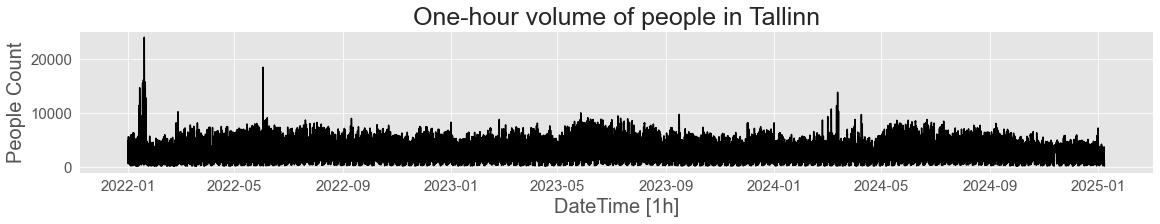

In [19]:
fig, ax = plt.subplots(figsize=(16,3)) #This is from the book.
plot_series(
    pfp,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="One-hour volume of people in Tallinn",
    ax = ax
)

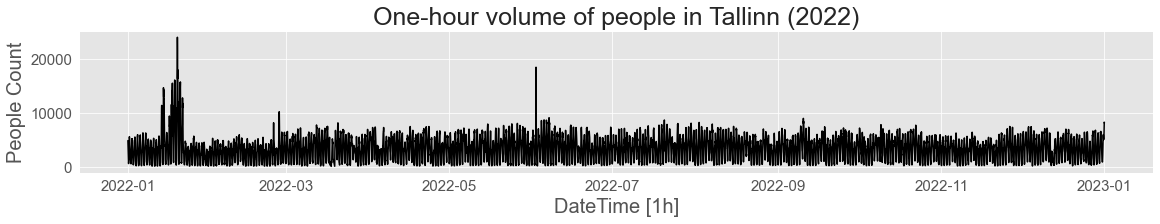

In [20]:
fig, ax = plt.subplots(figsize=(16,3))
plot_series(
    pfp[pfp["year"] == 2022],
    xlabel="DateTime [1h]", ylabel="People Count",
    title="One-hour volume of people in Tallinn (2022)",
    ax = ax
)

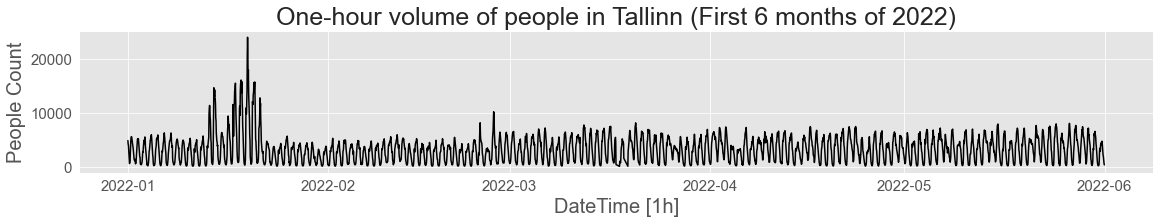

In [21]:
fig, ax = plt.subplots(figsize=(16,3))
plot_series(
    pfp[(pfp["year"] == 2022) & (pfp["month"] < 6)],
    xlabel="DateTime [1h]", ylabel="People Count",
    title="One-hour volume of people in Tallinn (First 6 months of 2022)",
    ax = ax
)

## 3. Model Training

### 3.1 MSTL Multiple Seasonal Periods
This model contains a lot of seasonal parts.

In [34]:
mstl_multissn = StatsForecast(
    models = [
        MSTL(
            season_length = [24, 24*7, 24*30, 24*365]
        )
    ],
    freq="1h" #The frequency of points in the dataset I guess? Or the frequency of generation of points?
)

### 3.2 Model fitting
It takes about 4 minutes for me in my laptop, locally

In [35]:
# This also comes from the book
mstl_msf = mstl_multissn.fit(pfp[pfp["year"] < 2023]) #Note I'm filtering to only have 2022
dcmp_mstl_msf = mstl_msf.fitted_[0,0].model_ #The variable name stands for "decomposition MSTL multiseasoned fit", which is a pretty long name
dcmp_mstl_msf.columns #You can see that it has the multiple seasons here as columns

Index(['data', 'trend', 'seasonal24', 'seasonal168', 'seasonal720',
       'seasonal8760', 'remainder'],
      dtype='object')

### 3.3 Model Plotting
This is from the book

data
trend
seasonal24
seasonal168
seasonal720
seasonal8760
remainder


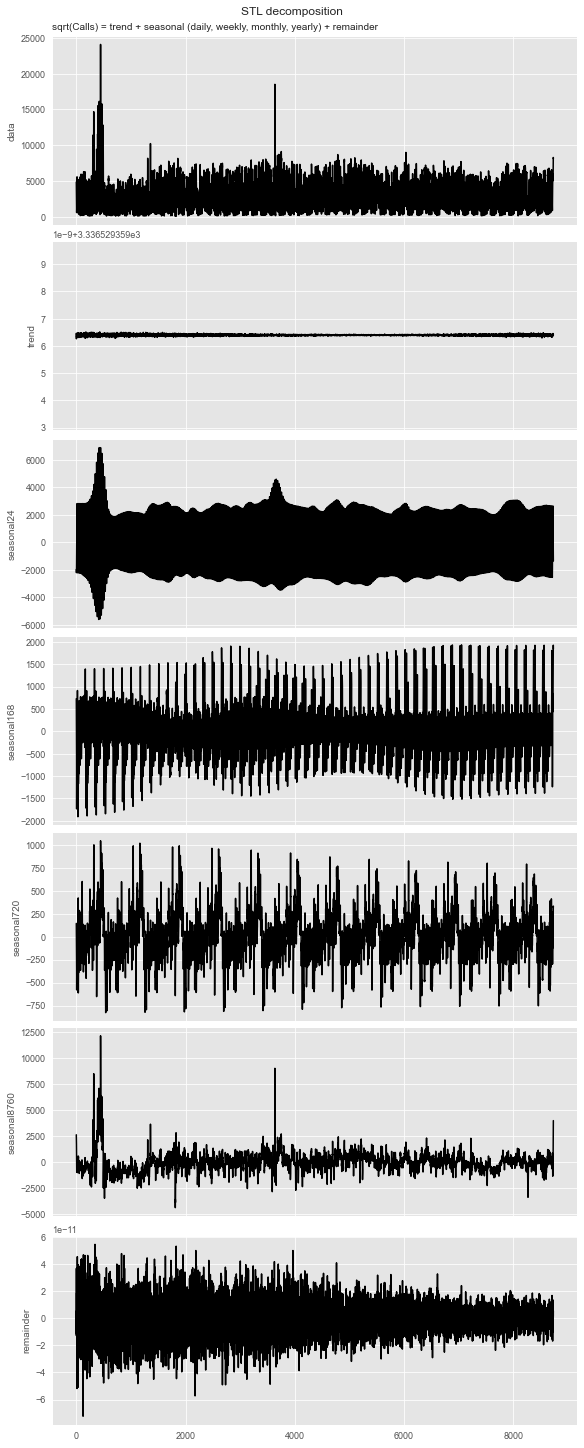

In [36]:
fig, axes = plt.subplots(7, figsize=(8, 20), sharex=True)
for (ax, column) in zip(axes, dcmp_mstl_msf.columns):
    print(column)
    sns.lineplot(data=dcmp_mstl_msf, x=dcmp_mstl_msf.index, y=column, ax=ax, color="k")
axes[0].set_title(
    "sqrt(Calls) = trend + seasonal (daily, weekly, monthly, yearly) + remainder",
    size="medium", loc="left")
axes[-1].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()

### 3.4 Making predictions!

In [37]:
mstl_msf_forecasts = mstl_msf.predict(
    h=24*(30*2),    # This is how many values to forecast, so "h" means horizon. Here I'm plotting two months (30days*2months)*24hours
    level=[80, 95]  # My guess is these are confidence interval shaded areas, but for some reasons in my plot I don't see them
)
mstl_msf_res = mstl_msf_forecasts.select_dtypes(include=np.number) #This is from the book.

### 3.5 Plotting the predictions!

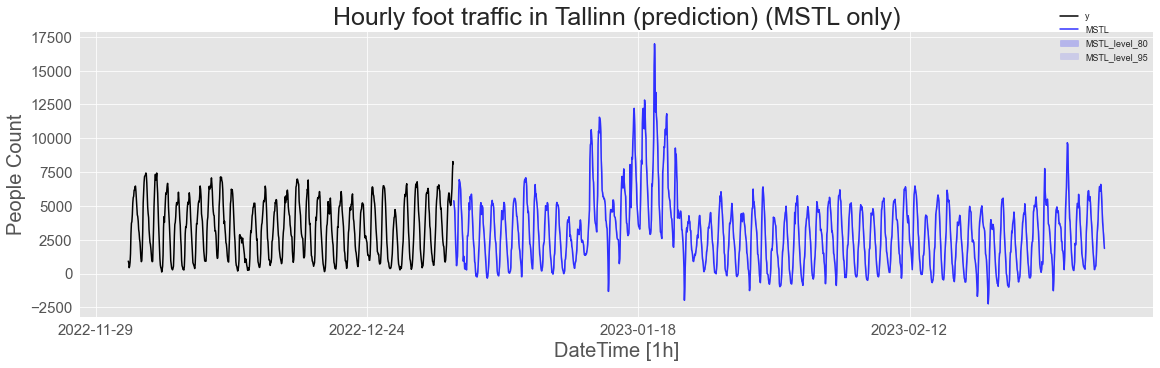

In [38]:
# Forecast, back-transform numerical results, and set ds with gaps
fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    pfp[pfp["year"] < 2023], #I want the year 2022's data to be in black
    mstl_msf_forecasts, #The forecasts we want to show
    level=[80, 95],     # again, seems like confidence interval stuff to me.
    max_insample_length=24*30, #How much to show from the black data (our training data). I'm showing the last month of the training data.
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) (MSTL only)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))

fig

3.6 Comparing with orginal values and evaluation

C:\Users\tanwa\AppData\Local\Temp\ipykernel_20660\1960753355.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


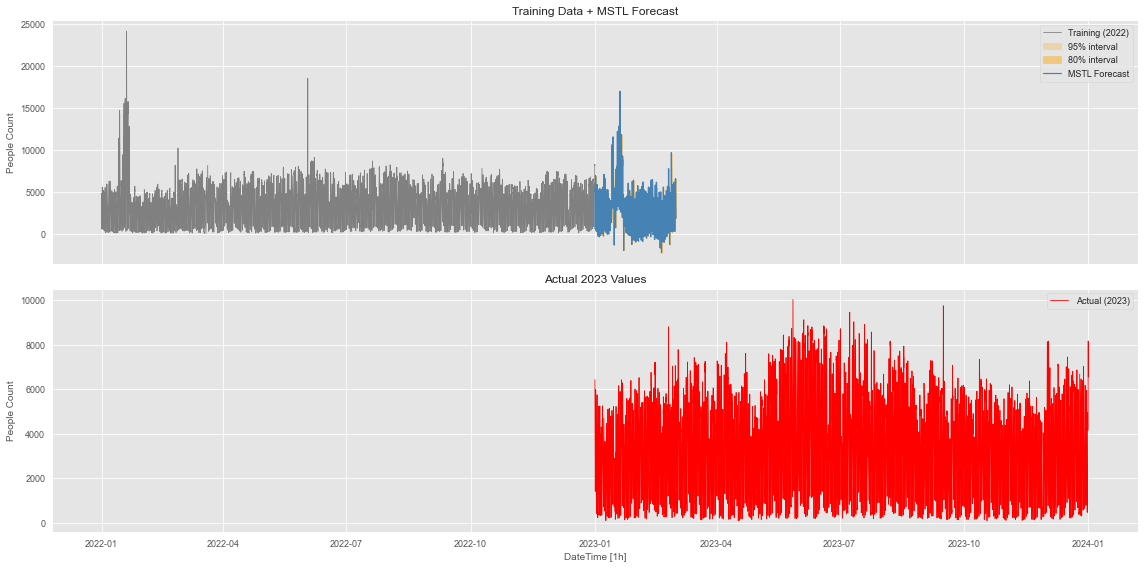

In [44]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Training + Forecast
train = pfp[pfp["year"] < 2023]
ax1.plot(train["ds"], train["y"], color="gray", linewidth=0.8, label="Training (2022)")
ax1.fill_between(mstl_msf_forecasts["ds"],
    mstl_msf_forecasts["MSTL-lo-95"], mstl_msf_forecasts["MSTL-hi-95"],
    color="orange", alpha=0.25, label="95% interval")
ax1.fill_between(mstl_msf_forecasts["ds"],
    mstl_msf_forecasts["MSTL-lo-80"], mstl_msf_forecasts["MSTL-hi-80"],
    color="orange", alpha=0.45, label="80% interval")
ax1.plot(mstl_msf_forecasts["ds"], mstl_msf_forecasts["MSTL"], 
    color="steelblue", linewidth=1.2, label="MSTL Forecast")

ax1.set_ylabel("People Count")
ax1.set_title("Training Data + MSTL Forecast")
ax1.legend()

# Actual 2023
actual_2023 = pfp[pfp["year"] == 2023]
ax2.plot(actual_2023["ds"], actual_2023["y"], color="red", linewidth=0.8, label="Actual (2023)")
ax2.set_ylabel("People Count")
ax2.set_xlabel("DateTime [1h]")
ax2.set_title("Actual 2023 Values")
ax2.legend()

plt.tight_layout()
plt.show()


In [59]:
mstl_msf_forecasts

,unique_id,ds,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95
0,all_sensors,2023-01-01 00:00:00,5387.711,5387.711,5387.711,5387.711,5387.711
1,all_sensors,2023-01-01 01:00:00,5026.460,5026.460,5026.460,5026.460,5026.460
2,all_sensors,2023-01-01 02:00:00,4660.983,4660.983,4660.983,4660.983,4660.983
3,all_sensors,2023-01-01 03:00:00,3333.467,3333.467,3333.467,3333.467,3333.467
4,all_sensors,2023-01-01 04:00:00,2250.614,2250.614,2250.614,2250.614,2250.614
...,...,...,...,...,...,...,...
1435,all_sensors,2023-03-01 19:00:00,3803.198,3803.198,3803.198,3803.198,3803.198
1436,all_sensors,2023-03-01 20:00:00,3341.061,3341.061,3341.061,3341.061,3341.061
1437,all_sensors,2023-03-01 21:00:00,2894.499,2894.499,2894.499,2894.499,2894.499
1438,all_sensors,2023-03-01 22:00:00,2293.756,2293.756,2293.756,2293.756,2293.756


In [60]:
# Evaluation

from utilsforecast.losses import mae, rmse, mape, mase
from utilsforecast.evaluation import evaluate

# Get the actual 2023 values
actual_2023 = pfp[pfp["year"] == 2023][["ds", "unique_id", "y"]]

#Merge actuals into the forecast DataFrame
forecasts_with_actuals = mstl_msf_forecasts.merge(
    actual_2023, on=["ds", "unique_id"], how="left"
)



In [61]:
# checking of null values that may arise post merging
forecasts_with_actuals["y"].isna().sum()

0

In [62]:
# getting the evaluation metric values

mase_24 = partial(mase, seasonality=168)

evaluate(
    forecasts_with_actuals,   # your predictions with ds, unique_id, model columns
    metrics=[mae, rmse, mape, mase_24],
    train_df=pfp[pfp["year"] < 2023]   # needed for mase baseline calculation
)


,unique_id,metric,MSTL
0,all_sensors,mae,1208.202
1,all_sensors,rmse,1832.495
2,all_sensors,mape,0.760
3,all_sensors,mase,1.448


In [63]:
pfp[pfp["year"] < 2023]["y"].max()

24103.0

Analysis:

- MAE = 1208.20
On average, forecast is off by around 1,208 people per hour. Maximum y value (total count of people at any given hour in 2022) is 24,1013. The esitmate indicates poor performance.

- RMSE = 1832
Significantly higher than MAE, meaning there are large spike errors pulling it up.

-  MAPE = 0.75 (Average of absolute_error/actual_value)
This model forecast is off by 75% on average. This is quite high,should be under 20% for good forecasting.

- MASE = 1.44
MASE > 1 means MSTL model is worse than saying "it'll be the same as last week at this hour"

## 4. Training a model with MSTL + ARIMA used for the remainder + Exogeneous Variables.

In [22]:
MSTL_arima_exo = MSTL(
    season_length=[24, 24*7, 24*30, 24*365], #This is the same
    trend_forecaster=AutoARIMA(season_length=1) #But now here ARIMA will take Trend + Remainder
)

marima_exo = StatsForecast(
    models = [MSTL_arima_exo],
    freq="1h"
)

### 4.1 Preparing the data
So for using Exogeneous Variables and maybe ARIMA as well, there are two problems I ran into
1) NaNs or missing values are not tolerated, so I interpolated.
2) Variables with high collinearity will make this crash. So I had to remove in_count and out_count, I assume that these two, being measures of the same thing, have high collinearity (they explain the same thing, right?)

In [23]:
pfp_exo = pfp[pfp["year"] < 2023]                           # Only 2022 to train the model
pfp_exo = fill_gaps(pfp_exo, freq="1h")                     # use the fill_gaps function first, since I saw the book has this.
pfp_exo["y"] = pfp_exo["y"].interpolate(method="linear")    # Interpolate on "y", maybe not necessary?
pfp_exo["humidity_mean"] = pfp_exo["humidity_mean"].interpolate(method="linear", limit_direction="both")    # This one is indeed necessary; limit_direction="both" means it can fill the first few values, which all have NaNs
#pfp_exo["humidity_mean"] = pfp_exo["humidity_mean"].bfill()            # You can also fill those starting NaNs using this instead.
pfp_exo["temp_mean"] = pfp_exo["temp_mean"].interpolate(method="linear", limit_direction="both")
#pfp_exo["temp_mean"] = pfp_exo["temp_mean"].bfill()
pfp_exo = pfp_exo[["unique_id", "ds", "y", "humidity_mean", "temp_mean"]]       # Now let's only take the values needed to eliminate "high collinearity" issues
pfp_exo

,unique_id,ds,y,humidity_mean,temp_mean
0,all_sensors,2022-01-01 00:00:00,4852.0,33.333,14.600
1,all_sensors,2022-01-01 01:00:00,4175.0,33.333,14.600
2,all_sensors,2022-01-01 02:00:00,4016.0,33.333,14.600
3,all_sensors,2022-01-01 03:00:00,3051.0,33.333,14.600
4,all_sensors,2022-01-01 04:00:00,2244.0,33.333,14.600
...,...,...,...,...,...
8755,all_sensors,2022-12-31 19:00:00,5653.0,86.176,5.869
8756,all_sensors,2022-12-31 20:00:00,6282.0,86.157,5.884
8757,all_sensors,2022-12-31 21:00:00,7448.0,86.139,5.613
8758,all_sensors,2022-12-31 22:00:00,8281.0,86.176,5.434


### 4.2 Training the model

In [24]:
marima_exo_fit = marima_exo.fit(pfp_exo)
dcmp_marima_exo = marima_exo_fit.fitted_[0,0].model_

### 4.3 Preparing the data we'll use for prediction
Now that we're using a model that takes into account Exogeneous values, we need to tell it what those values are forecasted to be in the future.
In other words, to predict it needs to know what the temperature and humidity are expected to be at each hour.

In [25]:
# pfp_2023_forpreds = pfp[pfp["year"] == 2023]
# pfp_2023_forpreds = pfp_2023_forpreds[["unique_id", "ds", "humidity_mean", "temp_mean"]]    # Note that I removed the "y" column here as well.
# pfp_2023_forpreds["humidity_mean"] = pfp_2023_forpreds["humidity_mean"].interpolate(method="linear", limit_direction="both")
# pfp_2023_forpreds["temp_mean"] = pfp_2023_forpreds["temp_mean"].interpolate(method="linear", limit_direction="both")
# pfp_2023_forpreds

pfp_2023_forpreds = pfp[pfp["year"] == 2023].copy()
pfp_2023_forpreds = fill_gaps(pfp_2023_forpreds, freq="1h")
pfp_2023_forpreds[["humidity_mean", "temp_mean"]] = pfp_2023_forpreds[["humidity_mean", "temp_mean"]].interpolate(method="linear", limit_direction="both")
pfp_2023_forpreds = pfp_2023_forpreds[["unique_id", "ds", "humidity_mean", "temp_mean"]]

In [26]:
pfp_2023_forpreds.to_csv("prediction_2023.csv")

### 4.4 Predicting!

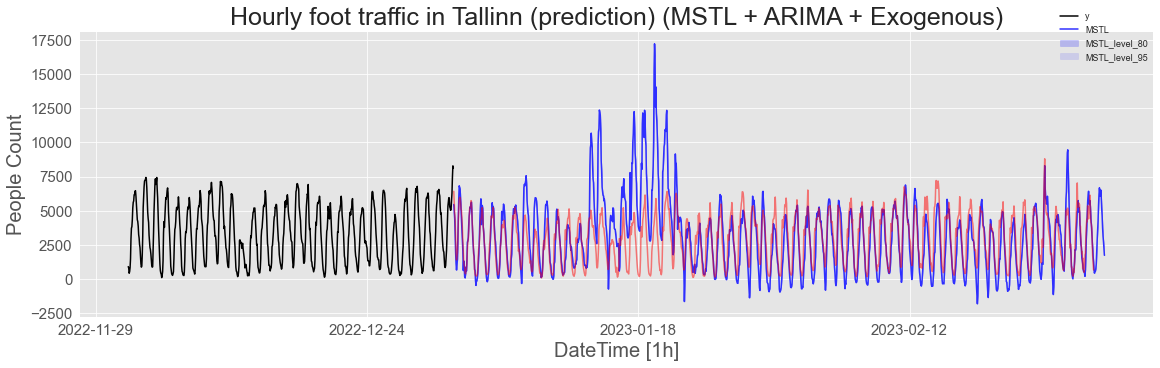

In [27]:
# Forecast, back-transform numerical results, and set ds with gaps
mexo_forecasts = marima_exo_fit.predict(
    h=24*(30*2),
    level=[80, 95],
    X_df=pfp_2023_forpreds.head(24*30*2) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
mexo_results = mexo_forecasts.select_dtypes(include=np.number)

fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    pfp[pfp["year"] < 2023],
    mexo_forecasts,
    level=[80, 95],
    max_insample_length=24*30,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) (MSTL + ARIMA + Exogenous)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))

first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 3)]

ax.plot(
    first_month_2023["ds"],
    first_month_2023["y"],
    color="red", alpha=0.5
)
fig

In [28]:
mexo_results

,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95
0,5460.527,5460.457,5460.481,5460.573,5460.597
1,4947.100,4947.002,4947.036,4947.165,4947.199
2,4408.250,4408.130,4408.171,4408.329,4408.371
3,3086.239,3086.100,3086.148,3086.330,3086.379
4,2007.972,2007.816,2007.870,2008.074,2008.128
...,...,...,...,...,...
1435,3739.995,3737.353,3738.268,3741.722,3742.637
1436,3135.168,3132.525,3133.440,3136.895,3137.810
1437,2740.098,2737.454,2738.369,2741.826,2742.741
1438,2193.910,2191.265,2192.181,2195.639,2196.554


In [29]:
actual_2023 = pfp[pfp["year"] == 2023].copy()
actual_2023 = fill_gaps(actual_2023, freq="1h")
actual_2023["y"] = actual_2023["y"].interpolate(method="linear", limit_direction="both")
actual_2023["unique_id"] = "all_sensors"

In [30]:
mexo_with_actuals = mexo_forecasts.merge(
    actual_2023[["ds", "y"]], on="ds", how="left"
)

In [31]:
print(mexo_with_actuals[["ds", "y", "MSTL"]].head(10))
print("NaN count:", mexo_with_actuals["y"].isna().sum())


                   ds       y      MSTL
0 2023-01-01 00:00:00  6420.0  5460.527
1 2023-01-01 01:00:00  5575.0  4947.100
2 2023-01-01 02:00:00  4818.0  4408.250
3 2023-01-01 03:00:00  4268.0  3086.239
4 2023-01-01 04:00:00  2984.0  2007.972
5 2023-01-01 05:00:00  1853.0  1135.917
6 2023-01-01 06:00:00  1406.0   671.374
7 2023-01-01 07:00:00  1613.0  1029.198
8 2023-01-01 08:00:00  1965.0  1447.637
9 2023-01-01 09:00:00  3083.0  3077.258
NaN count: 0


In [32]:
from utilsforecast.losses import mae, rmse, mape, mase
from utilsforecast.evaluation import evaluate
from functools import partial

mase_24 = partial(mase, seasonality=168)


In [33]:
mexo_results = evaluate(
    mexo_with_actuals,
    metrics=[mae, rmse, mape, mase_24],
    train_df=pfp[pfp["year"] < 2023]
)
mexo_results


,unique_id,metric,MSTL
0,all_sensors,mae,1219.219
1,all_sensors,rmse,1862.342
2,all_sensors,mape,0.749
3,all_sensors,mase,1.461


## 6. Making a Linear Combination of ARIMA + MSTL
Seems to me like that huge spike is because there's great importance being given to the past year's data, so it tries to foresee that spike.
Let's see if, by giving more weight to ARIMA, we can get something different!

In [34]:
simple_mstl = MSTL(
    season_length = [24, 24*7, 24*30, 24*365] #Just weekly and yearly patterns
)
simple_mstl_sf = StatsForecast(
    models = [simple_mstl],
    freq="1h"
)

In [35]:

simple_arima_sf = StatsForecast(
    models = [
        AutoARIMA(
            season_length=24,
            seasonal=True,
            max_p= 2,
            max_d=1,
            max_q=2
        )
    ], # "1" to disable seasonality since MSTL is already capturing it.
    freq="1h"
)

In [36]:
smsf_fit = simple_mstl_sf.fit(pfp_exo)
dcmp_smsf_fit = smsf_fit.fitted_[0,0].model_

In [37]:
sarf_fit = simple_arima_sf.fit(pfp_exo.tail(24*30))
dcmp_sarf_fit = sarf_fit.fitted_[0,0].model_

In [38]:
smsf_forecasts = smsf_fit.predict(
    h=24*(30*4),
    level=[80, 95],
    X_df=pfp_2023_forpreds.head(24*30*4) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
smsf_results = smsf_forecasts.select_dtypes(include=np.number)

In [40]:

sarf_forecasts = sarf_fit.predict(
    h=24*(30*4),
    level=[80, 95],
    X_df=pfp_2023_forpreds.head(24*30*4) #Whatever data you provide, the number of data points must match the number of data points you want in the "horizon" argument ("h")
)
sarf_results = sarf_forecasts.select_dtypes(include=np.number)

In [41]:
smsf_forecasts

,unique_id,ds,MSTL,MSTL-lo-95,MSTL-lo-80,MSTL-hi-80,MSTL-hi-95
0,all_sensors,2023-01-01 00:00:00,5460.527,5460.527,5460.527,5460.527,5460.527
1,all_sensors,2023-01-01 01:00:00,4947.100,4947.100,4947.100,4947.100,4947.100
2,all_sensors,2023-01-01 02:00:00,4408.250,4408.250,4408.250,4408.250,4408.250
3,all_sensors,2023-01-01 03:00:00,3086.239,3086.239,3086.239,3086.239,3086.239
4,all_sensors,2023-01-01 04:00:00,2007.972,2007.972,2007.972,2007.972,2007.972
...,...,...,...,...,...,...,...
2875,all_sensors,2023-04-30 19:00:00,2822.297,2822.297,2822.297,2822.297,2822.297
2876,all_sensors,2023-04-30 20:00:00,2522.046,2522.046,2522.046,2522.046,2522.046
2877,all_sensors,2023-04-30 21:00:00,1883.396,1883.396,1883.396,1883.396,1883.396
2878,all_sensors,2023-04-30 22:00:00,1493.897,1493.897,1493.897,1493.897,1493.897


In [42]:
sarf_forecasts

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,all_sensors,2023-01-01 00:00:00,7397.441,6730.001,6961.025,7833.857,8064.882
1,all_sensors,2023-01-01 01:00:00,6516.355,5473.014,5834.151,7198.558,7559.695
2,all_sensors,2023-01-01 02:00:00,5779.842,4460.612,4917.244,6642.440,7099.072
3,all_sensors,2023-01-01 03:00:00,4991.018,3492.915,4011.462,5970.575,6489.121
4,all_sensors,2023-01-01 04:00:00,4342.195,2719.254,3281.011,5403.380,5965.137
...,...,...,...,...,...,...,...
2875,all_sensors,2023-04-30 19:00:00,6509.258,1850.136,3462.822,9555.693,11168.379
2876,all_sensors,2023-04-30 20:00:00,6238.201,1579.054,3191.749,9284.653,10897.347
2877,all_sensors,2023-04-30 21:00:00,5901.251,1242.085,2854.786,8947.716,10560.417
2878,all_sensors,2023-04-30 22:00:00,5473.085,813.905,2426.611,8519.560,10132.266


In [112]:
import numpy as np

In [43]:
y_hat = 0.9*smsf_forecasts["MSTL"] + 0.1*sarf_results["AutoARIMA"]

y_df = pd.DataFrame({
    "unique_id": smsf_forecasts["unique_id"],
    "ds": smsf_forecasts["ds"],
    "ensemble_y": y_hat
})
y_df

,unique_id,ds,ensemble_y
0,all_sensors,2023-01-01 00:00:00,5654.218
1,all_sensors,2023-01-01 01:00:00,5104.026
2,all_sensors,2023-01-01 02:00:00,4545.410
3,all_sensors,2023-01-01 03:00:00,3276.717
4,all_sensors,2023-01-01 04:00:00,2241.394
...,...,...,...
2875,all_sensors,2023-04-30 19:00:00,3190.993
2876,all_sensors,2023-04-30 20:00:00,2893.661
2877,all_sensors,2023-04-30 21:00:00,2285.182
2878,all_sensors,2023-04-30 22:00:00,1891.816


In [44]:
ensemble_with_actuals = y_df.merge(
    actual_2023[["ds", "unique_id", "y"]], on=["ds", "unique_id"], how="left"
)

In [45]:
print(ensemble_with_actuals[["ds", "y", "ensemble_y"]].head(10))
print("NaN count:", ensemble_with_actuals["y"].isna().sum())

                   ds       y  ensemble_y
0 2023-01-01 00:00:00  6420.0    5654.218
1 2023-01-01 01:00:00  5575.0    5104.026
2 2023-01-01 02:00:00  4818.0    4545.410
3 2023-01-01 03:00:00  4268.0    3276.717
4 2023-01-01 04:00:00  2984.0    2241.394
5 2023-01-01 05:00:00  1853.0    1429.141
6 2023-01-01 06:00:00  1406.0    1012.815
7 2023-01-01 07:00:00  1613.0    1363.766
8 2023-01-01 08:00:00  1965.0    1766.753
9 2023-01-01 09:00:00  3083.0    3316.372
NaN count: 0


In [46]:
ensemble_results = evaluate(
    ensemble_with_actuals,
    metrics=[mae, rmse, mape, mase_24],
    train_df= pfp_exo
)
ensemble_results

,unique_id,metric,ensemble_y
0,all_sensors,mae,1095.006
1,all_sensors,rmse,1540.377
2,all_sensors,mape,0.626
3,all_sensors,mase,1.322


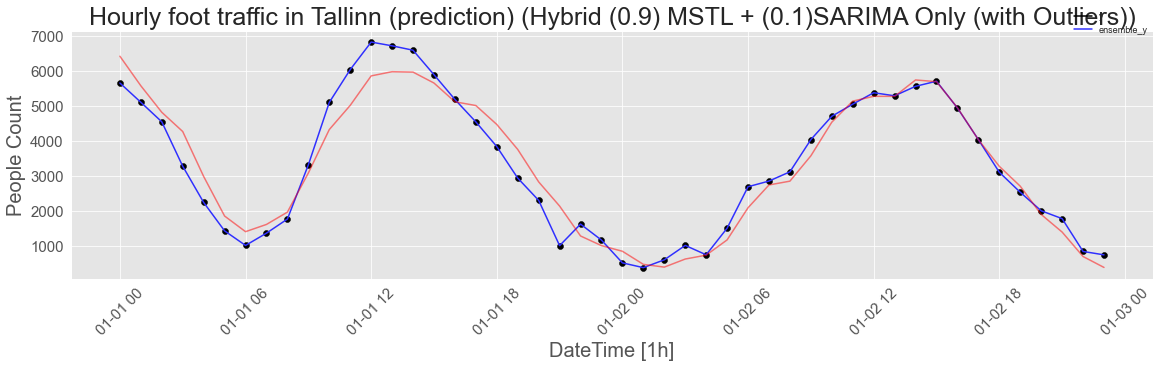

In [48]:
fig, ax = plt.subplots(figsize=(16, 5))

plot_series(
    pfp[pfp["year"] < 2023].tail(48),
    y_df.head(48),
    # level=[80, 95],
    max_insample_length=0,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) (Hybrid (0.9) MSTL + (0.1)SARIMA Only (with Outliers))",
    palette="black_and_blue", rm_legend=False, ax=ax)
#ax.xaxis.set_major_locator(MaxNLocator(4))
# ax.xaxis.set_major_locator(matplotdates.HourLocator(interval=1))
# ax.xaxis.set_major_formatter(matplotdates.DateFormatter('%H:%M'))
ax.tick_params(axis="x",rotation=45)

ax.scatter(y_df.head(48)["ds"], y_df.head(48)["ensemble_y"])


first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 3)]

ax.plot(
   first_month_2023["ds"].head(48),
   first_month_2023["y"].head(48),
   color="red", alpha=0.5
)
fig

In [49]:
y_hat = 0.9*(smsf_forecasts["MSTL"]) + 0.1*sarf_results["AutoARIMA"]

y_df = pd.DataFrame({
    "unique_id": smsf_forecasts["unique_id"],
    "ds": smsf_forecasts["ds"],
    "ensemble_y": y_hat
})

ensemble_with_actuals = y_df.merge(
    actual_2023[["ds", "unique_id", "y"]], on=["ds", "unique_id"], how="left"
)

ensemble_results = evaluate(
    ensemble_with_actuals,
    metrics=[mae, rmse, mape, mase_24],
    train_df= pfp_exo
)
ensemble_results



,unique_id,metric,ensemble_y
0,all_sensors,mae,1095.006
1,all_sensors,rmse,1540.377
2,all_sensors,mape,0.626
3,all_sensors,mase,1.322


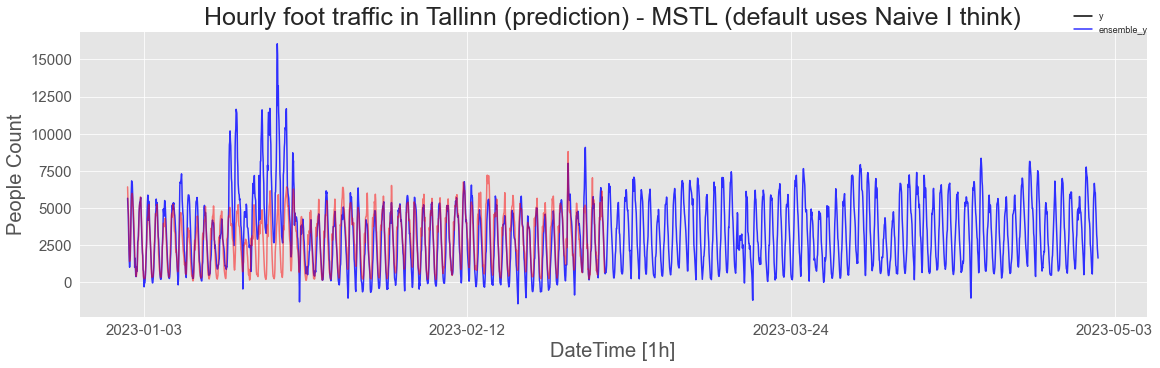

In [50]:
fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    pfp[pfp["year"] < 2023],
    y_df,
    #level=[80, 95],
    max_insample_length=0,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) - MSTL (default uses Naive I think)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))

first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 3)]

ax.plot(
    first_month_2023["ds"],
    first_month_2023["y"],
    color="red", alpha=0.5
)
fig

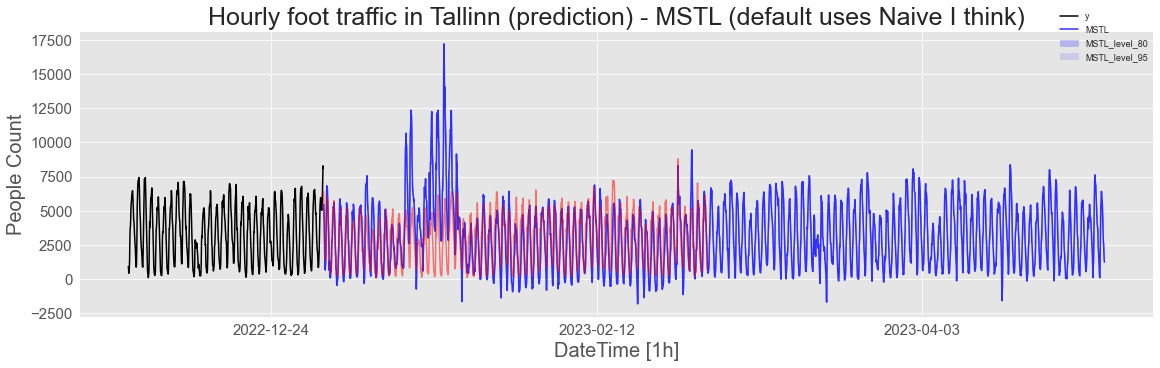

In [51]:
#Let's try plotting MSTL only
fig, ax = plt.subplots(figsize=(16, 5))
plot_series(
    pfp[pfp["year"] < 2023],
    smsf_forecasts,
    level=[80, 95],
    max_insample_length=24*30,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) - MSTL (default uses Naive I think)",
    palette="black_and_blue", rm_legend=False, ax=ax)
ax.xaxis.set_major_locator(MaxNLocator(4))

first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 3)]

ax.plot(
    first_month_2023["ds"],
    first_month_2023["y"],
    color="red", alpha=0.5
)
fig

In [125]:
import matplotlib.dates as matplotdates

In [126]:
y_df.head(24)

,unique_id,ds,ensemble_y
0,all_sensors,2023-01-01 00:00:00,6622.676
1,all_sensors,2023-01-01 01:00:00,5888.653
2,all_sensors,2023-01-01 02:00:00,5231.205
3,all_sensors,2023-01-01 03:00:00,4229.107
4,all_sensors,2023-01-01 04:00:00,3408.506
5,all_sensors,2023-01-01 05:00:00,2895.261
6,all_sensors,2023-01-01 06:00:00,2720.022
7,all_sensors,2023-01-01 07:00:00,3036.609
8,all_sensors,2023-01-01 08:00:00,3362.335
9,all_sensors,2023-01-01 09:00:00,4511.940


In [52]:
y_hat = 0.0*smsf_forecasts["MSTL"] + 1.0*sarf_results["AutoARIMA"]

y_df = pd.DataFrame({
    "unique_id": smsf_forecasts["unique_id"],
    "ds": smsf_forecasts["ds"],
    "ensemble_y": y_hat
})



In [53]:
ensemble_with_actuals = y_df.merge(
    actual_2023[["ds", "unique_id", "y"]], on=["ds", "unique_id"], how="left"
)

ensemble_results = evaluate(
    ensemble_with_actuals,
    metrics=[mae, rmse, mape, mase_24],
    train_df= pfp_exo
)
ensemble_results



,unique_id,metric,ensemble_y
0,all_sensors,mae,1352.826
1,all_sensors,rmse,1779.358
2,all_sensors,mape,1.243
3,all_sensors,mase,1.633


In [132]:
ensemble_with_actuals

,unique_id,ds,ensemble_y,y
0,all_sensors,2023-01-01 00:00:00,7397.441,6420.0
1,all_sensors,2023-01-01 01:00:00,6516.355,5575.0
2,all_sensors,2023-01-01 02:00:00,5779.842,4818.0
3,all_sensors,2023-01-01 03:00:00,4991.018,4268.0
4,all_sensors,2023-01-01 04:00:00,4342.195,2984.0
...,...,...,...,...
1435,all_sensors,2023-03-01 19:00:00,3928.703,3332.0
1436,all_sensors,2023-03-01 20:00:00,3683.042,2616.0
1437,all_sensors,2023-03-01 21:00:00,3332.081,2636.0
1438,all_sensors,2023-03-01 22:00:00,2914.833,1441.0


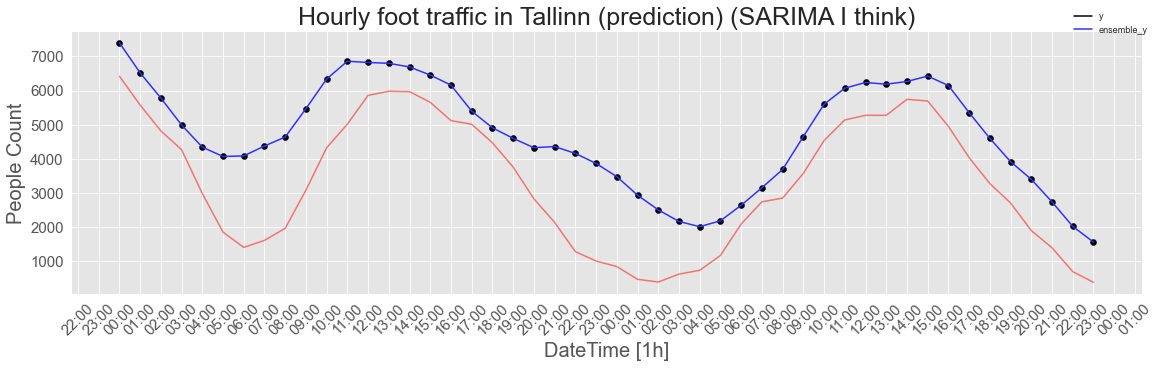

In [144]:
fig, ax = plt.subplots(figsize=(16, 5))

plot_series(
    pfp[pfp["year"] < 2023].tail(48),
    y_df.head(48),
    # level=[80, 95],
    max_insample_length=0,
    xlabel="DateTime [1h]", ylabel="People Count",
    title="Hourly foot traffic in Tallinn (prediction) (SARIMA I think)",
    palette="black_and_blue", rm_legend=False, ax=ax)
#ax.xaxis.set_major_locator(MaxNLocator(4))
ax.xaxis.set_major_locator(matplotdates.HourLocator(interval=1))
ax.xaxis.set_major_formatter(matplotdates.DateFormatter('%H:%M'))
ax.tick_params(axis="x",rotation=45)

ax.scatter(y_df.head(48)["ds"], y_df.head(48)["ensemble_y"])


first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 3)]

ax.plot(
   first_month_2023["ds"].head(48),
   first_month_2023["y"].head(48),
   color="red", alpha=0.5
)
fig

In [97]:
pfp[pfp["y"] <30]

,year,month,day,hour,y,in_count_sum,out_count_sum,humidity_mean,temp_mean,ds,unique_id


## Trying out a Prophet model

In [54]:
pmodel = Prophet(
    #yearly_seasonality=True,
   # monthly_seasonality=True, #Doesn't exist, but we can add one
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale = 0.001
    # We could also add holidays here with `holidays=holiday_df`
)
pmodel.add_regressor("temp_mean")
pmodel.add_regressor("humidity_mean")

In [55]:
pfp_prophet = pfp_exo
pfp_prophet

,unique_id,ds,y,humidity_mean,temp_mean
0,all_sensors,2022-01-01 00:00:00,4852.0,33.333,14.600
1,all_sensors,2022-01-01 01:00:00,4175.0,33.333,14.600
2,all_sensors,2022-01-01 02:00:00,4016.0,33.333,14.600
3,all_sensors,2022-01-01 03:00:00,3051.0,33.333,14.600
4,all_sensors,2022-01-01 04:00:00,2244.0,33.333,14.600
...,...,...,...,...,...
8755,all_sensors,2022-12-31 19:00:00,5653.0,86.176,5.869
8756,all_sensors,2022-12-31 20:00:00,6282.0,86.157,5.884
8757,all_sensors,2022-12-31 21:00:00,7448.0,86.139,5.613
8758,all_sensors,2022-12-31 22:00:00,8281.0,86.176,5.434


In [56]:
pmodel.fit(pfp_prophet)

22:06:24 - cmdstanpy - INFO - Chain [1] start processing
22:06:25 - cmdstanpy - INFO - Chain [1] done processing


In [57]:
# Future dataframe is needed for predictions
future_df = pfp_2023_forpreds
future_df = future_df[["ds", "temp_mean", "humidity_mean"]] # It's the only one that is really needed.
future_df

,ds,temp_mean,humidity_mean
0,2023-01-01 00:00:00,4.858,86.204
1,2023-01-01 01:00:00,4.474,86.222
2,2023-01-01 02:00:00,4.006,86.185
3,2023-01-01 03:00:00,3.392,86.120
4,2023-01-01 04:00:00,2.931,86.120
...,...,...,...
8755,2023-12-31 19:00:00,-5.360,87.537
8756,2023-12-31 20:00:00,-5.935,87.481
8757,2023-12-31 21:00:00,-6.123,87.602
8758,2023-12-31 22:00:00,-5.790,87.741


In [58]:
pforecast = pmodel.predict(
    future_df.head(30)
)
pforecast["unique_id"] = "all_sensors"
print(pforecast.columns)
pforecast

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'daily', 'daily_lower', 'daily_upper', 'extra_regressors_additive',
       'extra_regressors_additive_lower', 'extra_regressors_additive_upper',
       'humidity_mean', 'humidity_mean_lower', 'humidity_mean_upper',
       'temp_mean', 'temp_mean_lower', 'temp_mean_upper', 'weekly',
       'weekly_lower', 'weekly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat',
       'unique_id'],
      dtype='object')


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,temp_mean_lower,temp_mean_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,unique_id
0,2023-01-01 00:00:00,3562.936,-298.261,2905.292,3562.936,3562.936,-2326.889,-2326.889,-2326.889,-2305.355,...,-107.553,-107.553,277.766,277.766,277.766,0.0,0.0,0.0,1236.047,all_sensors
1,2023-01-01 01:00:00,3562.990,-582.366,2593.499,3562.990,3562.990,-2610.501,-2610.501,-2610.501,-2550.417,...,-116.749,-116.749,248.608,248.608,248.608,0.0,0.0,0.0,952.489,all_sensors
2,2023-01-01 02:00:00,3563.043,-936.233,2343.739,3563.043,3563.043,-2763.618,-2763.618,-2763.618,-2662.871,...,-127.962,-127.962,218.768,218.768,218.768,0.0,0.0,0.0,799.426,all_sensors
3,2023-01-01 03:00:00,3563.097,-653.281,2553.156,3563.097,3563.097,-2672.985,-2672.985,-2672.985,-2527.857,...,-142.654,-142.654,188.398,188.398,188.398,0.0,0.0,0.0,890.112,all_sensors
4,2023-01-01 04:00:00,3563.151,-218.713,2806.932,3563.151,3563.151,-2256.175,-2256.175,-2256.175,-2069.286,...,-153.667,-153.667,157.651,157.651,157.651,0.0,0.0,0.0,1306.976,all_sensors
5,2023-01-01 05:00:00,3563.205,467.753,3515.210,3563.205,3563.205,-1552.697,-1552.697,-1552.697,-1325.649,...,-162.952,-162.952,126.679,126.679,126.679,0.0,0.0,0.0,2010.507,all_sensors
6,2023-01-01 06:00:00,3563.258,1240.143,4447.434,3563.258,3563.258,-715.589,-715.589,-715.589,-450.537,...,-169.910,-169.910,95.634,95.634,95.634,0.0,0.0,0.0,2847.669,all_sensors
7,2023-01-01 07:00:00,3563.312,2105.686,5108.916,3563.312,3563.312,71.281,71.281,71.281,370.422,...,-173.323,-173.323,64.666,64.666,64.666,0.0,0.0,0.0,3634.593,all_sensors
8,2023-01-01 08:00:00,3563.366,2698.822,5743.372,3563.366,3563.366,694.077,694.077,694.077,1022.501,...,-170.597,-170.597,33.921,33.921,33.921,0.0,0.0,0.0,4257.443,all_sensors
9,2023-01-01 09:00:00,3563.419,3200.098,6230.062,3563.419,3563.419,1156.218,1156.218,1156.218,1503.676,...,-157.501,-157.501,3.541,3.541,3.541,0.0,0.0,0.0,4719.638,all_sensors


In [59]:
pforecast = pmodel.predict(
    future_df
)
pforecast["unique_id"] = "all_sensors"

In [60]:
pfdf = pforecast[['ds', 'yhat']].rename(columns={'yhat': 'y_prophet'})
pfdf['unique_id'] = 'all_sensors'
pfdf

,ds,y_prophet,unique_id
0,2023-01-01 00:00:00,1236.047,all_sensors
1,2023-01-01 01:00:00,952.489,all_sensors
2,2023-01-01 02:00:00,799.426,all_sensors
3,2023-01-01 03:00:00,890.112,all_sensors
4,2023-01-01 04:00:00,1306.976,all_sensors
...,...,...,...
8755,2023-12-31 19:00:00,3149.219,all_sensors
8756,2023-12-31 20:00:00,2535.005,all_sensors
8757,2023-12-31 21:00:00,1978.885,all_sensors
8758,2023-12-31 22:00:00,1521.691,all_sensors


In [61]:
prophet_with_actuals = pfdf.merge(
    actual_2023[["ds", "unique_id", "y"]], on=["ds", "unique_id"], how="left"
)

In [62]:
print(prophet_with_actuals[["ds", "y", "y_prophet"]].head(10))
print("NaN count:", prophet_with_actuals["y"].isna().sum())


                   ds       y  y_prophet
0 2023-01-01 00:00:00  6420.0   1236.047
1 2023-01-01 01:00:00  5575.0    952.489
2 2023-01-01 02:00:00  4818.0    799.426
3 2023-01-01 03:00:00  4268.0    890.112
4 2023-01-01 04:00:00  2984.0   1306.976
5 2023-01-01 05:00:00  1853.0   2010.507
6 2023-01-01 06:00:00  1406.0   2847.669
7 2023-01-01 07:00:00  1613.0   3634.593
8 2023-01-01 08:00:00  1965.0   4257.443
9 2023-01-01 09:00:00  3083.0   4719.638
NaN count: 0


In [63]:
prophet_results = evaluate(
    prophet_with_actuals,
    metrics=[mae, rmse, mape, partial(mase, seasonality=168)],
    train_df=pfp_exo
)
prophet_results

,unique_id,metric,y_prophet
0,all_sensors,mae,858.419
1,all_sensors,rmse,1072.906
2,all_sensors,mape,0.583
3,all_sensors,mase,1.036


In [64]:
first_month_2023 = pfp[(pfp["year"] == 2023) & (pfp["month"] < 4)]

plt.figure(figsize=(16, 7))
plt.plot(pfdf["ds"].head(30*24*3), pfdf["y"].head(30*24*3), color="b")
plt.plot(
    first_month_2023["ds"],
    first_month_2023["y"],
    color="red", alpha=0.5
)
plt.title("Foot Traffic in Tallinn 2023 (Prophet)")
plt.xlabel("Time")
plt.ylabel("Count")

KeyError: 'y'

<Figure size 1152x504 with 0 Axes>